## 1. Import Required Libraries

We need these libraries for our data analysis, visualization, preprocessing, machine learning model building, optimization and evaluation.

# iPhone Sales Price Prediction using Machine Learning

**Course:** BAN644/BAN744 Applied Machine Learning for Business Analytics with Python  
**Project Type:** Regression Problem  
**Dataset:** `iphone_sales_dataset.csv`

## Project Objective

The objective of this project is to build a machine learning regression model that can predict iPhone sales price using business-related features such as country, iPhone model, storage, color, quantity, sale date, and payment method.

This project follows the required machine learning workflow:

1. Data collection
2. Data preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature selection
5. Model building
6. Model optimization
7. Model evaluation
8. Business insights and recommendations


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the Dataset

The dataset file should be uploaded to Google Colab with this exact name:

`iphone_sales_dataset.csv`

In [5]:
df = pd.read_csv("iphone_sales_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (100, 10)


,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method
0,1001,Customer_1,USA,iPhone 13,256GB,Purple,5,1817,2025-05-01,Debit Card
1,1002,Customer_2,Canada,iPhone 12,256GB,Blue,1,998,2025-03-05,PayPal
2,1003,Customer_3,Canada,iPhone 15 Pro Max,512GB,Black,5,876,2025-01-25,Credit Card
3,1004,Customer_4,USA,iPhone 15 Pro Max,512GB,Black,2,1290,2025-03-24,Debit Card
4,1005,Customer_5,USA,iPhone 15,128GB,Blue,3,1092,2025-02-01,Debit Card


## 3. Basic Dataset Understanding

In this step, we check the columns, data types, missing values, and duplicate rows.

In [6]:
print("Column names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Column names:
Index(['Order_ID', 'Customer_Name', 'Country', 'iPhone_Model', 'Storage',
       'Color', 'Quantity', 'Price', 'Sale_Date', 'Payment_Method'],
      dtype='object')

Data types:
Order_ID           int64
Customer_Name     object
Country           object
iPhone_Model      object
Storage           object
Color             object
Quantity           int64
Price              int64
Sale_Date         object
Payment_Method    object
dtype: object

Missing values in each column:
Order_ID          0
Customer_Name     0
Country           0
iPhone_Model      0
Storage           0
Color             0
Quantity          0
Price             0
Sale_Date         0
Payment_Method    0
dtype: int64

Number of duplicate rows:
0


## 4. Data Preprocessing

Here we clean the dataset.

We will:
- Remove duplicate rows
- Convert `Sale_Date` into date format
- Extract useful date features such as month and day of week
- Drop unnecessary columns such as `Order_ID` and `Customer_Name`

In [7]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert Sale_Date to datetime format
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])

# Create new useful date-based features
df["Sale_Month"] = df["Sale_Date"].dt.month
df["Sale_Day"] = df["Sale_Date"].dt.day
df["Sale_DayOfWeek"] = df["Sale_Date"].dt.dayofweek

print("Dataset after preprocessing:")
df.head()

Dataset after preprocessing:


,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method,Sale_Month,Sale_Day,Sale_DayOfWeek
0,1001,Customer_1,USA,iPhone 13,256GB,Purple,5,1817,2025-05-01,Debit Card,5,1,3
1,1002,Customer_2,Canada,iPhone 12,256GB,Blue,1,998,2025-03-05,PayPal,3,5,2
2,1003,Customer_3,Canada,iPhone 15 Pro Max,512GB,Black,5,876,2025-01-25,Credit Card,1,25,5
3,1004,Customer_4,USA,iPhone 15 Pro Max,512GB,Black,2,1290,2025-03-24,Debit Card,3,24,0
4,1005,Customer_5,USA,iPhone 15,128GB,Blue,3,1092,2025-02-01,Debit Card,2,1,5


## 5. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset using summary statistics and charts.

In [8]:
df.describe(include="all")

,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method,Sale_Month,Sale_Day,Sale_DayOfWeek
count,100.000000,100,100,100,100,100,100.000000,100.000000,100,100,100.000000,100.00000,100.00000
unique,NaN,100,6,6,3,5,NaN,NaN,NaN,4,NaN,NaN,NaN
top,NaN,Customer_1,USA,iPhone 14 Pro,256GB,Blue,NaN,NaN,NaN,Debit Card,NaN,NaN,NaN
freq,NaN,1,22,24,38,25,NaN,NaN,NaN,38,NaN,NaN,NaN
mean,1050.500000,NaN,NaN,NaN,NaN,NaN,3.330000,1468.750000,2025-02-27 12:28:48,NaN,2.430000,15.72000,3.24000
min,1001.000000,NaN,NaN,NaN,NaN,NaN,1.000000,718.000000,2025-01-01 00:00:00,NaN,1.000000,1.00000,0.00000
25%,1025.750000,NaN,NaN,NaN,NaN,NaN,2.000000,1123.750000,2025-01-25 00:00:00,NaN,1.000000,8.00000,2.00000
50%,1050.500000,NaN,NaN,NaN,NaN,NaN,3.000000,1571.500000,2025-03-02 00:00:00,NaN,2.500000,15.00000,3.00000
75%,1075.250000,NaN,NaN,NaN,NaN,NaN,5.000000,1794.250000,2025-03-28 00:00:00,NaN,3.000000,24.25000,5.00000
max,1100.000000,NaN,NaN,NaN,NaN,NaN,5.000000,1992.000000,2025-05-01 00:00:00,NaN,5.000000,30.00000,6.00000


### 5.1 Price Distribution

This chart shows how iPhone prices are distributed in the dataset.

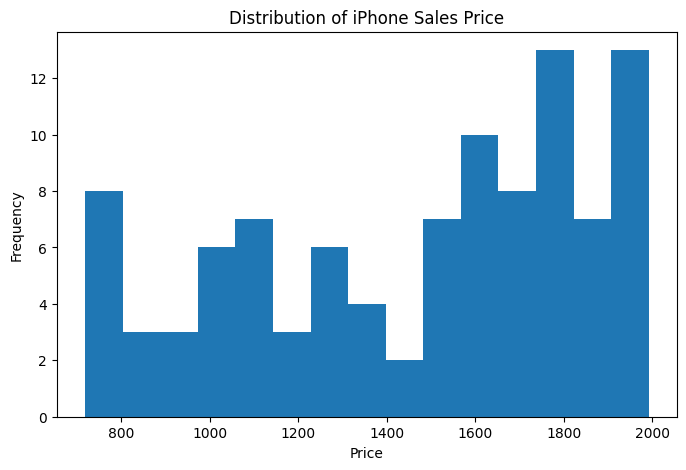

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=15)
plt.title("Distribution of iPhone Sales Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### 5.2 Average Price by iPhone Model

This chart helps identify which iPhone models have higher average prices.

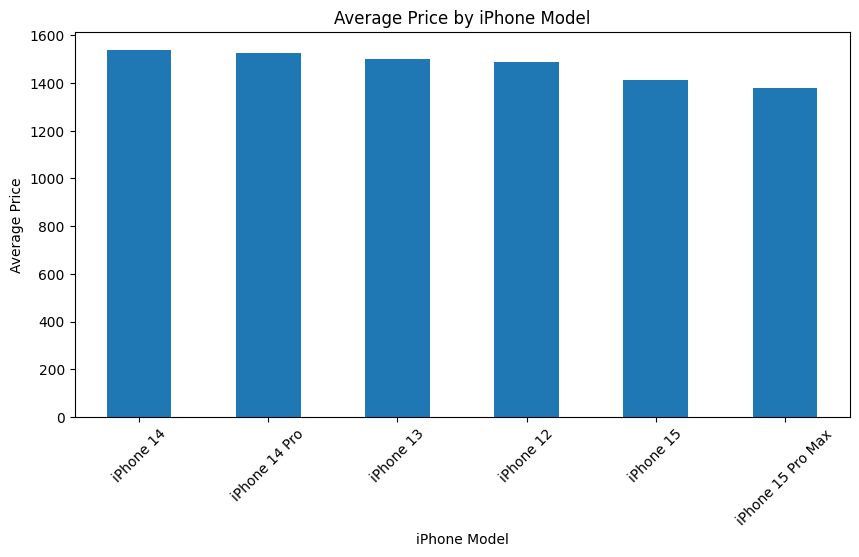

,Price
iPhone_Model,
iPhone 14,1537.090909
iPhone 14 Pro,1525.500000
iPhone 13,1501.214286
iPhone 12,1489.538462
iPhone 15,1413.000000
iPhone 15 Pro Max,1380.272727


In [10]:
avg_price_model = df.groupby("iPhone_Model")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_price_model.plot(kind="bar")
plt.title("Average Price by iPhone Model")
plt.xlabel("iPhone Model")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

avg_price_model

### 5.3 Total Quantity Sold by Country

This chart shows which countries generated higher sales quantity.

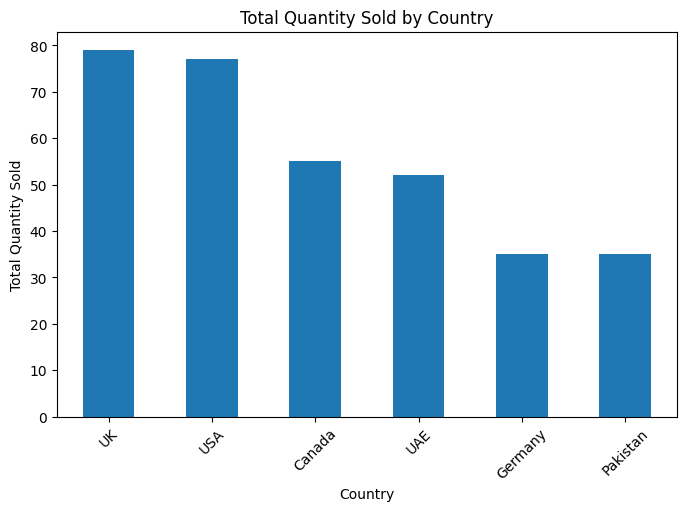

,Quantity
Country,
UK,79
USA,77
Canada,55
UAE,52
Germany,35
Pakistan,35


In [11]:
quantity_country = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
quantity_country.plot(kind="bar")
plt.title("Total Quantity Sold by Country")
plt.xlabel("Country")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

quantity_country

### 5.4 Average Price by Storage

This chart shows the relationship between storage size and average price.

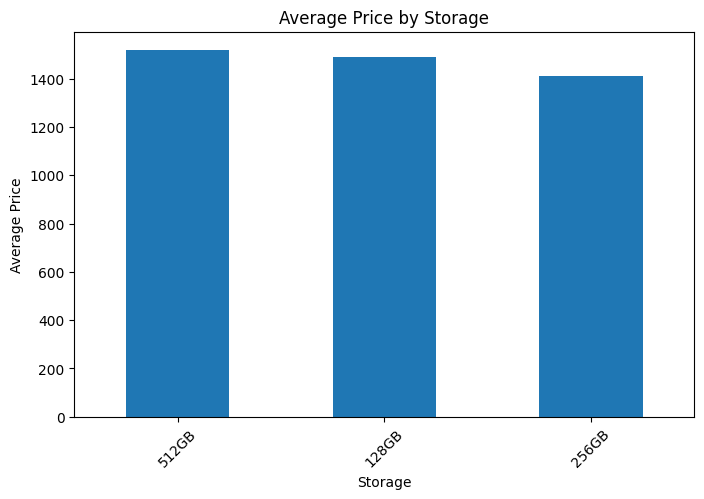

,Price
Storage,
512GB,1519.107143
128GB,1490.470588
256GB,1412.210526


In [12]:
avg_price_storage = df.groupby("Storage")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_price_storage.plot(kind="bar")
plt.title("Average Price by Storage")
plt.xlabel("Storage")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

avg_price_storage

### 5.5 Payment Method Analysis

This chart shows how frequently different payment methods are used.

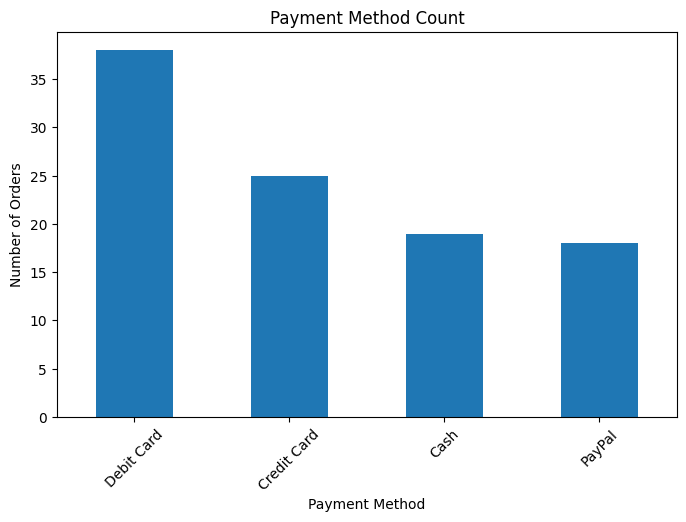

,count
Payment_Method,
Debit Card,38
Credit Card,25
Cash,19
PayPal,18


In [13]:
payment_count = df["Payment_Method"].value_counts()

plt.figure(figsize=(8,5))
payment_count.plot(kind="bar")
plt.title("Payment Method Count")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

payment_count

## 6. Feature Selection

We select the columns that are useful for predicting iPhone price.

Target variable:

`Price`

Selected features:

- Country
- iPhone_Model
- Storage
- Color
- Quantity
- Payment_Method
- Sale_Month
- Sale_Day
- Sale_DayOfWeek

We remove `Order_ID`, `Customer_Name`, and `Sale_Date` because they are not useful directly for prediction.

In [14]:
target_column = "Price"

feature_columns = [
    "Country",
    "iPhone_Model",
    "Storage",
    "Color",
    "Quantity",
    "Payment_Method",
    "Sale_Month",
    "Sale_Day",
    "Sale_DayOfWeek"
]

X = df[feature_columns]
y = df[target_column]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

X.head()

Feature data shape: (100, 9)
Target data shape: (100,)


,Country,iPhone_Model,Storage,Color,Quantity,Payment_Method,Sale_Month,Sale_Day,Sale_DayOfWeek
0,USA,iPhone 13,256GB,Purple,5,Debit Card,5,1,3
1,Canada,iPhone 12,256GB,Blue,1,PayPal,3,5,2
2,Canada,iPhone 15 Pro Max,512GB,Black,5,Credit Card,1,25,5
3,USA,iPhone 15 Pro Max,512GB,Black,2,Debit Card,3,24,0
4,USA,iPhone 15,128GB,Blue,3,Debit Card,2,1,5


## 7. Train-Test Split

We divide the data into training and testing sets.

- Training data: used to train the machine learning model
- Testing data: used to evaluate model performance on unseen data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training feature shape: (80, 9)
Testing feature shape: (20, 9)


## 8. Preprocessing Pipeline

Machine learning models cannot directly understand text columns such as country, model, color, and payment method.

So we use:

- `OneHotEncoder` for categorical columns
- `StandardScaler` for numerical columns
- `SimpleImputer` to handle missing values

In [16]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numeric features: ['Quantity', 'Sale_Month', 'Sale_Day', 'Sale_DayOfWeek']
Categorical features: ['Country', 'iPhone_Model', 'Storage', 'Color', 'Payment_Method']


## 9. Model Building

We will train and compare three regression models:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

During model building, Random Forest Regressor performed best overall, with the lowest RMSE (395.80) and the highest R² score (-0.428) among the three models. However, its MAE is slightly higher than Linear Regression.

Linear Regression is simple and easy to interpret, but its negative R² shows weak predictive performance. Decision Tree Regressor performed the worst, with the highest error values and lowest R², suggesting poor generalization.

Although Random Forest is the preferred model, all models have negative R² scores, meaning they perform worse than a simple average-based prediction. Therefore, further improvement is needed through better feature selection, data preprocessing, outlier handling, and hyperparameter tuning.

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42)
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,333.745427,160955.58126,401.192698,-0.467035
1,Decision Tree Regressor,417.850000,274389.45000,523.821964,-1.500931
2,Random Forest Regressor,342.316000,156654.05848,395.795476,-0.427828


## 10. Model Optimization

Now we optimize the Random Forest model using GridSearchCV.

Optimization means testing different model settings to find the best combination.


In [18]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Best Cross Validation Score:
-180029.58379975468


After model optimization, the best parameters selected for the Random Forest model were:

max_depth = None, min_samples_leaf = 4, min_samples_split = 10, and n_estimators = 100.

This means the model uses 100 decision trees, allows trees to grow fully, but controls overfitting by requiring at least 10 samples to split a node and 4 samples in each leaf node. These settings help make the model more stable and reduce overfitting

## 11. Final Model Evaluation

Now we evaluate the optimized Random Forest model on the test data.

In [19]:
best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_mse = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_final)

print("Final Optimized Random Forest Performance")
print("----------------------------------------")
print("MAE:", final_mae)
print("MSE:", final_mse)
print("RMSE:", final_rmse)
print("R2 Score:", final_r2)

Final Optimized Random Forest Performance
----------------------------------------
MAE: 322.54380773050684
MSE: 130896.95810307897
RMSE: 361.79684645264524
R2 Score: -0.19306444404939094


The optimized Random Forest model improved compared to the earlier models, with lower MAE, MSE, and RMSE. This shows that hyperparameter tuning helped reduce prediction errors and made the model more stable.

However, the R² score is still negative (-0.193), meaning the model still performs worse than a simple average-based prediction. So, although the optimized model is better than the initial models, it is not yet reliable for strong prediction.

The main trade-off is that Random Forest provides better accuracy and handles nonlinear patterns better than Linear Regression, but it is less interpretable and requires more computation. The tuning settings also reduce overfitting by controlling tree splits and leaf size, but this may slightly limit the model’s ability to capture complex patterns.

Overall, the optimized Random Forest is the best model so far, but further improvement is needed through better data preprocessing, feature engineering, outlier handling, and possibly testing advanced models such as Gradient Boosting or XGBoost.

## 12. Actual vs Predicted Price

This table compares the real iPhone price with the predicted price.

In [20]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_final
})

comparison_df.head(10)

,Actual Price,Predicted Price
0,1229,1516.612137
1,1829,1414.168591
2,1977,1412.175282
3,1094,1378.008490
4,1667,1530.763312
5,1034,1358.415988
6,1964,1552.854990
7,1579,1206.823179
8,1857,1438.716390
9,1817,1343.969006


The comparison shows that the model predictions are mostly around 1200–1550, while the actual prices vary from 1034 to 1977.

The model overestimated lower actual prices, such as:

1229 → 1516.61 and 1094 → 1378.01

It also underestimated higher actual prices, such as:

1829 → 1414.17, 1977 → 1412.18, and 1964 → 1552.85

This indicates that the model is predicting values closer to the middle range and is not capturing very high or very low prices accurately. Overall, the model has some prediction ability, but it still needs improvement because several predicted prices are far from the actual prices.

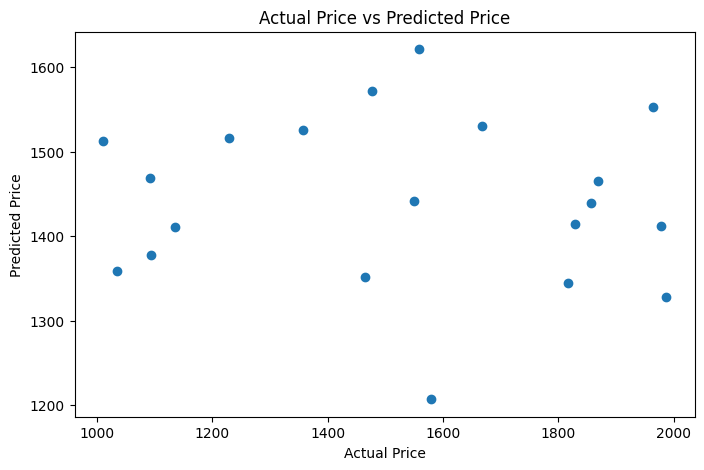

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_final)
plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## 13. Business Insights and Recommendations

The graph shows that the model's predicted prices are mostly concentrated between 1200 and 1600, while the actual prices are spread more widely from around 1000 to 2000. This means the model is not fully capturing the actual price variation.

Key Predictors and Their Impact

Based on the graph, the predictors used in the model are not strong enough to clearly separate low-price and high-price products. If the predictors were highly effective, the points would show a clearer upward pattern, where higher actual prices would also have higher predicted prices. However, the scattered points show that the model gives similar predicted values for many different actual prices.

This suggests that important pricing factors may be missing from the dataset, such as product quality, brand value, demand, market trend, customer preference, seasonality, or competitor pricing. As a result, the model is predicting prices closer to the average instead of accurately identifying low and high price ranges.

Business Application

Businesses can still use this model as a basic supporting tool to estimate general price ranges. It may help identify whether a product is likely to fall within a mid-level price category. The model can also support initial pricing decisions, budgeting, and product comparison.

However, businesses should not fully depend on this model for final pricing decisions because it may overestimate low-priced products and underestimate high-priced products. Human judgment, market research, and competitor analysis should be used together with the model output.

Limitations and Improvements

The main limitation is that the model does not follow the actual price pattern strongly. The scattered points and lack of clear upward trend indicate weak prediction accuracy. The model struggles especially with extreme prices, meaning very low and very high prices are not predicted well.

To improve the model, more relevant business features should be added, such as brand, product category, customer demand, sales history, season, discount, and competitor price. Outliers should be checked, data quality should be improved, and advanced models like XGBoost, Gradient Boosting, LightGBM, or CatBoost can be tested for better performance.

# Conclusion

The model can predict prices within a general mid-range, but it does not accurately follow the actual price pattern. It tends to overestimate lower prices and underestimate higher prices, showing weak prediction performance. Therefore, the model can be used only as a basic supporting tool, but further improvement is needed through better features, data cleaning, and advanced modeling techniques.